In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-evaluation-data-set/car_evaluation.csv


In [2]:
data = '/kaggle/input/car-evaluation-data-set/car_evaluation.csv'
df = pd.read_csv(data,header = None)

## Importing necessary Libraries

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

## Exploratory Data Analysis

In [4]:
df.shape

(1728, 7)

In [5]:
df.head(5)

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [6]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
for col in col_names:
    print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [9]:
# doors and person is categorical in nature with class as an target variable 
df["class"].value_counts()


class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

## Checking for missing Values

In [10]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [11]:
X = df.drop(['class'],axis = 1)
y = df['class']

## Train Test Splits

In [12]:
# split X and y into training and test data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

In [13]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((1382, 6), (346, 6))

In [14]:
# Divide your training data (X_train and y_train) into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [15]:
# check the shape of X_train and X_val

X_train.shape, X_val.shape

((1105, 6), (277, 6))

## Feature Engineering

In [16]:
X_train.dtypes
# since these are catrgorical will need to encode these 
X_train.head(5)

,buying,maint,doors,persons,lug_boot,safety
1605,low,med,5more,4,med,low
458,high,vhigh,2,more,big,high
924,med,vhigh,4,2,big,low
8,vhigh,vhigh,2,2,big,high
472,high,vhigh,3,4,med,med


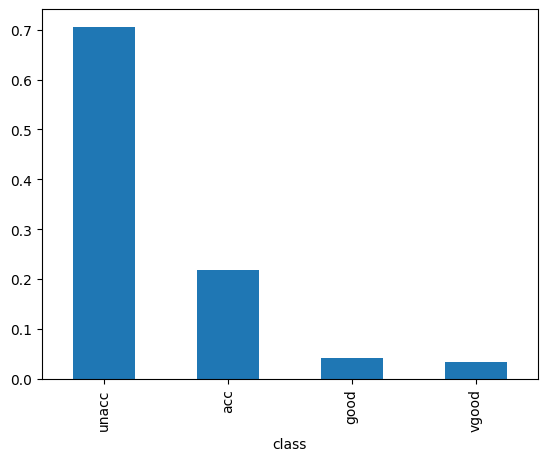

In [17]:
y_train.value_counts(normalize=True).plot(kind='bar');

## Encoding Variables

In [18]:
import category_encoders as ce 
encoder = ce.OrdinalEncoder(cols=['buying','maint','doors','persons','lug_boot','safety'])
X_train  = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [19]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1605,1,1,1,1,1,1
458,2,2,2,2,2,2
924,3,2,3,3,2,1
8,4,2,2,3,2,2
472,2,2,4,1,1,3


# Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier
clg_gini = DecisionTreeClassifier(criterion='gini',max_depth=3, random_state=0)
clg_gini.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [21]:
y_pred_gini = clg_gini.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.8237


In [23]:
y_pred_train_gini = clg_gini.predict(X_train)

y_pred_train_gini

array(['unacc', 'acc', 'unacc', ..., 'unacc', 'unacc', 'acc'],
      dtype=object)

In [24]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.7946


In [25]:
print('Training set score: {:.4f}'.format(clg_gini.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clg_gini.score(X_test, y_test)))

Training set score: 0.7946
Test set score: 0.8237


## Visualising Results

[Text(0.4, 0.875, 'x[5] <= 1.5\ngini = 0.451\nsamples = 1105\nvalue = [241, 47, 780, 37]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 375\nvalue = [0, 0, 375, 0]'),
 Text(0.6, 0.625, 'x[3] <= 2.5\ngini = 0.576\nsamples = 730\nvalue = [241, 47, 405, 37]'),
 Text(0.4, 0.375, 'x[0] <= 3.5\ngini = 0.63\nsamples = 493\nvalue = [241, 47, 168, 37]'),
 Text(0.2, 0.125, 'gini = 0.64\nsamples = 372\nvalue = [193, 47, 95, 37]'),
 Text(0.6, 0.125, 'gini = 0.479\nsamples = 121\nvalue = [48, 0, 73, 0]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 237\nvalue = [0, 0, 237, 0]')]

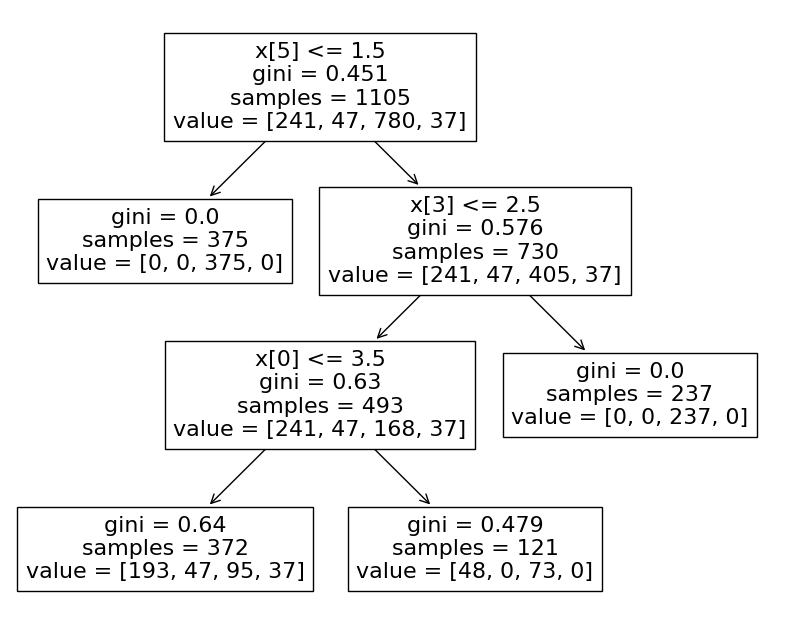

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

from sklearn import tree
tree.plot_tree(clg_gini.fit(X_train, y_train)) 

Confusion matrix

 [[ 68   0  15   0]
 [ 11   0   0   0]
 [ 18   0 217   0]
 [ 17   0   0   0]]


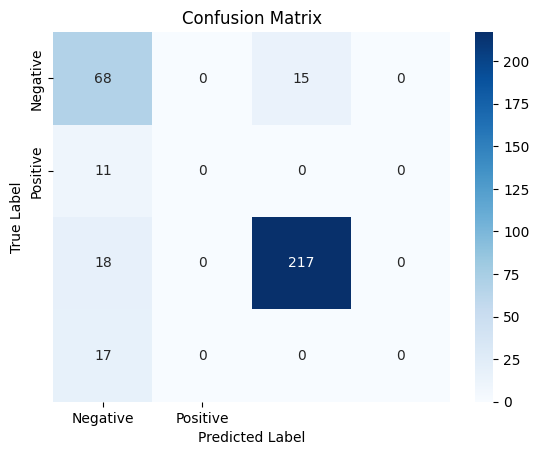

In [27]:
# Print the Confusion Matrix and slice it into four pieces
cm = confusion_matrix(y_test, y_pred_gini)

print('Confusion matrix\n\n', cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
clf_gini = RandomForestClassifier()
# fit the model
clf_gini.fit(X_train, y_train)

RandomForestClassifier()

In [30]:
y_pred_gini = clf_gini.predict(X_test)
y_pred_gini

array(['unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'acc',
       'unacc', 'acc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'acc', 'unacc', 'acc', 'good', 'good', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'acc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'good', 'unacc',
       'acc', 'unacc', 'unacc', 'unacc', 'vgood', 'unacc', 'acc', 'acc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'vgood', 'unacc', 'unacc', 'acc',
       'vgood', 'acc', 'unacc', 'acc', 'vgood', 'acc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'good', 'unacc', 'unacc', 'unacc',
       'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 

## Model Accuracy

In [31]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score: 0.9104


## Visualizing Results

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

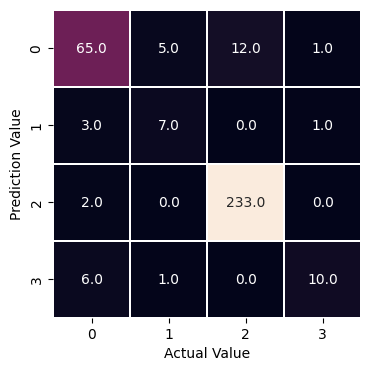

In [32]:
cm = confusion_matrix(y_test, y_pred_gini)
plt.figure(figsize=(4,4))
sns.heatmap(cm,annot=True,fmt='0.1f', linewidth = 0.1 , square = True , cbar = False)
plt.ylabel("Prediction Value")
plt.xlabel("Actual Value")
plt

In [33]:
print( classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

         acc       0.86      0.78      0.82        83
        good       0.54      0.64      0.58        11
       unacc       0.95      0.99      0.97       235
       vgood       0.83      0.59      0.69        17

    accuracy                           0.91       346
   macro avg       0.79      0.75      0.77       346
weighted avg       0.91      0.91      0.91       346



# SVM

In [34]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [35]:
y_pred = svm_model.predict(X_test)

## Model Accuracy

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8353


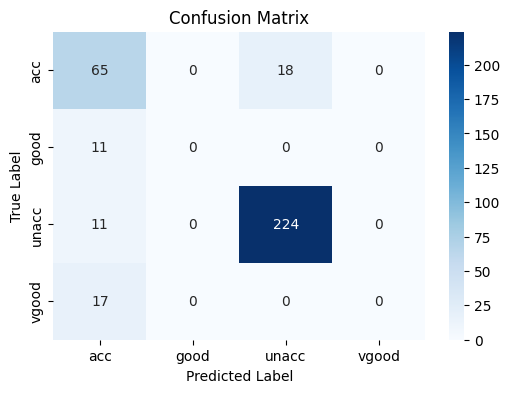

In [37]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [38]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         acc       0.62      0.78      0.70        83
        good       0.00      0.00      0.00        11
       unacc       0.93      0.95      0.94       235
       vgood       0.00      0.00      0.00        17

    accuracy                           0.84       346
   macro avg       0.39      0.43      0.41       346
weighted avg       0.78      0.84      0.80       346



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
